# Proyecto final integrador · Fase 4
## Características de los alojamientos Airbnb y diferencias de precio en Santiago

**Curso:** MCDI500 — Programación para la Ciencia de Datos  
**Grupo:** 3  
**Integrantes:** Felipe Ignacio Gutiérrez Castro, Alfredo Abraham Schussler, Rolando Donoso Guerra y Cristián Vasquez Muñoz  
**Docente:** Dr. Omar Salinas Silva

## Contexto y problemática

El conjunto de datos de Inside Airbnb reúne anuncios de alojamientos en Santiago con información sobre ubicación, capacidad, características físicas, anfitriones y evaluaciones. Los precios presentan diferencias importantes entre anuncios, por lo que el proyecto busca describir qué características se relacionan con esas diferencias mediante un procesamiento reproducible y visualizaciones analíticas.

## Pregunta de investigación

¿Qué características observables de los alojamientos (ubicación, anfitrión, comuna, etc.) se relacionan con las diferencias de precio?

## Objetivo general

Describir las asociaciones entre las características de los alojamientos Airbnb y su precio por noche en el conjunto analizado.

## Objetivos específicos

1. Caracterizar la distribución de anuncios entre comunas y comparar precios según comuna y tipo de habitación.
2. Examinar cómo varían la mediana y la dispersión del precio según la capacidad de personas.
3. Identificar las asociaciones entre las características numéricas de los alojamientos y el precio mediante correlaciones de Spearman.

## Alcance

El análisis es descriptivo y exploratorio. Estudia los anuncios presentes en el archivo utilizado y no estima efectos causales ni desarrolla un modelo predictivo. Los precios corresponden a valores publicados, no a ingresos efectivamente obtenidos por los anfitriones.

## Restricciones y supuestos

- La base representa una captura de anuncios y no un seguimiento temporal.
- La cantidad de anuncios difiere considerablemente entre comunas y tipos de habitación.
- Las variables imputadas pueden modificar la dispersión y las asociaciones observadas.
- Una fila representa un registro del archivo; sin una verificación específica del identificador, no se afirma que todas las filas correspondan a alojamientos únicos.
- La capacidad indica el máximo de personas admitidas, no huéspedes efectivamente alojados.
- Se asume que el precio utilizado está expresado en CLP y corresponde a una unidad comparable entre registros. Esta interpretación debe contrastarse con la documentación de la fuente.

## Integración de las fases

| Fase | Aporte al proyecto |
|---|---|
| F1 | Definición del problema, objetivos y organización del entorno reproducible. |
| F2 | Selección, limpieza y transformación de los datos. |
| F3 | Organización del procesamiento mediante módulos y POO, validación, recursividad y mediciones de eficiencia. |
| F4 | Integración del flujo y comunicación de hallazgos mediante visualizaciones, discusión y conclusiones. |

El notebook utiliza los módulos de `src/`, compara el procesamiento con la salida de F2 y conserva una copia interpretable para el análisis final.

## 1. Los conceptos que realizamos

| Concepto | Qué es | En nuestro ejemplo |
|---|---|---|
| **Clase** | El molde o plantilla. | `class Preprocesador:` |
| **Objeto** | Algo creado a partir de la clase. | `prep = Preprocesador("datos.csv")` |
| **Atributo** | Un dato que vive dentro del objeto. | `self.df` (la tabla) |
| **Método** | Una acción del objeto (una función dentro de la clase). | `prep.limpiar()` |
| **`self`** | La palabra que usa el objeto para referirse **a sí mismo**. | `self.df = ...` |

Y un método especial: **`__init__`** es el **constructor**: se ejecuta automáticamente cuando creas el
objeto y sirve para dejar listos sus atributos iniciales.


## 2. Arquitectura de Preprocesamiento y Transformación (POO)

El proyecto separa los datos originales, los datos procesados, los notebooks y el código fuente para mantener un flujo organizado, reproducible y trazable entre las fases del análisis (Salinas, 2026).

El notebook integra los módulos de `src/`, distribuyendo las responsabilidades de carga, limpieza, transformación y validación:

- **`src/carga.py`:** carga el archivo original comprimido.
- **`src/limpieza.py`:** selecciona las variables de estudio, prepara las filas e imputa valores nulos mediante `LimpiadorAirbnb`.
- **`src/transformacion.py`:** implementa los transformadores, las estrategias de escalamiento y el orquestador `Pipeline`.
- **`src/validacion.py`:** verifica la matriz resultante y permite compararla con el conjunto procesado de la Fase 2.

La arquitectura de transformación utiliza una clase abstracta `Transformador`, que define la interfaz común `ajustar()` y `transformar()`. Las clases especializadas implementan estas operaciones según su tarea, mientras que `Pipeline` recorre los pasos mediante una misma interfaz, aplicando polimorfismo. El patrón Strategy permite elegir entre `EstrategiaStandard` y `EstrategiaRobust` sin modificar la lógica de coordinación del pipeline.

La entrada es el archivo original `Data/Raw/listings.csv.gz`, ubicado respecto de la raíz del repositorio. El procesamiento retoma las decisiones de preparación de la Fase 2 y compara los resultados para verificar la continuidad entre fases.

El flujo ejecutado es: carga → selección de variables y preparación de filas → imputación → copia interpretable → codificación One-Hot y escalamiento → validación frente a F2 → traducción de la copia interpretable → análisis descriptivo → generación de metadatos mediante recursividad → mediciones de eficiencia → exportación → visualizaciones e interpretación.

Carga de librerias os, sys, timeit, tracemalloc, numpy, pandas, matplotlib.pyplot, Path

In [1]:
import os
import sys
import timeit
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%load_ext autoreload
%autoreload 2

# Configurar ruta relativa para que el notebook (en F3/notebooks/) reconozca la carpeta src/
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Carga de módulos modularizados creados por el grupo
from src.carga import cargar_datos
from src.validacion import Validacion
from src.limpieza import LimpiadorAirbnb
from src.limpieza import preparar_filas 
from src.transformacion import (
    Pipeline,
    CodificadorNominal,
    EscaladorFlexible,
    EstrategiaStandard,
    EstrategiaRobust
)

%matplotlib inline
np.random.seed(42)

# CONFIGURACIÓN GENERAL DEL PROYECTO
RUTA_DATOS = Path("../../Data/Processed/airbnb_f4.csv")
RUTA_RAW = Path("../../Data/Raw/listings.csv.gz")
if not RUTA_RAW.exists():
    RUTA_RAW = Path("../../Data/Raw/listings.csv.gz")

print("Ruta del dataset:", RUTA_RAW)
print("¿Existe el archivo?:", RUTA_RAW.exists())

# Variable central utilizada en el análisis
PRECIO = "price_quote_price_per_night" if "price_quote_price_per_night" in pd.read_csv(RUTA_RAW, nrows=1).columns else "precio_por_noche"

Ruta del dataset: ..\..\Data\Raw\listings.csv.gz
¿Existe el archivo?: True


Los datos se mantienen en DataFrames explícitos que se transfieren entre los componentes del procesamiento. `df_raw` contiene la entrada original, `df_limpio` conserva las variables seleccionadas después de la limpieza y `df_transformado` contiene la matriz codificada y escalada.

Antes de transformar las variables se crea `df_analisis`, una copia interpretable que conserva las categorías y el precio en CLP. Posteriormente se traducen sus nombres y los tipos de habitación para facilitar las tablas, los gráficos y la interpretación de resultados.

## 3. Ejecución del Pipeline POO y Conservación de la Base de Análisis

En esta sección se ejecuta la canalización de datos utilizando los módulos desarrollados en la carpeta `src/`.

Para la manipulación, limpieza y transformación de los datos se utiliza la biblioteca pandas, que proporciona estructuras y herramientas orientadas al análisis de datos tabulares en Python (The pandas development team, 2024).

## Decisiones de preparación de los datos

| Decisión | Justificación | Consecuencia o límite |
|---|---|---|
| Seleccionar las variables de estudio | Mantiene el procesamiento vinculado con la pregunta de investigación. | El análisis no considera características excluidas, como equipamiento detallado. |
| Excluir registros sin precio | No es posible comparar precios cuando falta la variable central. | Las conclusiones describen los registros con precio conocido. |
| Imputar determinadas variables numéricas mediante mediana | Conserva registros y utiliza una medida menos sensible a valores extremos. | Introduce valores repetidos y puede modificar dispersión y correlaciones. |
| Codificar categorías mediante One-Hot Encoding | Evita imponer un orden artificial a comuna, propiedad y habitación. | Aumenta el número de columnas y requiere controlar el vocabulario aprendido. |
| Escalar variables explicativas mediante RobustScaler | Centra mediante mediana y escala mediante rango intercuartílico. | No elimina valores extremos ni garantiza una distribución normal. |
| Mantener el precio en CLP | Conserva la interpretación de las diferencias de precio. | Los gráficos requieren escalas adecuadas para su amplia variación. |
| Conservar `df_analisis` antes de transformar | Permite analizar categorías y unidades originales. | Esta copia contiene las imputaciones realizadas previamente. |

El procesamiento actual se ajusta sobre el conjunto completo para un análisis descriptivo. No se presenta como una evaluación predictiva con entrenamiento y prueba independientes. Si se incorpora un modelo posteriormente, la partición debe realizarse antes de aprender medianas, categorías y parámetros de escalamiento.

In [2]:
# 1. CARGA DEL ARCHIVO COMPRIMIDO
RUTA_RAW = Path("../../Data/Raw/listings.csv.gz")
if not RUTA_RAW.exists():
    RUTA_RAW = Path("../../Data/Raw/listings.csv.gz")

df_raw = cargar_datos(RUTA_RAW)


# 2. APLICAR LIMPIEZA
# Paso A: Seleccionar variables de la Fase 2 y descartar filas sin precio
df_seleccion, informe_limpieza = preparar_filas(df_raw)
print(f"✓ Filas recibidas: {informe_limpieza['filas_recibidas']:,} | Utiles: {informe_limpieza['filas_utilizables']:,}")

# Paso B: Imputar nulos usando .ajustar_transformar
limpiador = LimpiadorAirbnb()
df_limpio = limpiador.ajustar_transformar(df_seleccion)

# Guardar copia interpretable para análisis descriptivo
df_analisis = df_limpio.copy()
print("✓ Base limpia y copia interpretable creada en 'df_analisis'.")

Datos cargados correctamente: 18,534 filas y 90 columnas
✓ Filas recibidas: 18,534 | Utiles: 17,687
✓ Base limpia y copia interpretable creada en 'df_analisis'.


In [3]:
# 3. DEFINICIÓN DE SCALER A UTILIZAR
df_standard = df_limpio.copy()
df_robust = df_limpio.copy()
Standard = [
    EscaladorFlexible(
        columnas=[
            'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'hosts_time_as_host_years', 'number_of_reviews',
            'review_scores_rating', 'review_scores_accuracy',
            'review_scores_cleanliness', 'review_scores_checkin',
            'review_scores_communication', 'review_scores_location',
            'review_scores_value'
        ],
        estrategia=EstrategiaStandard()
    )
]
Robust = [
    EscaladorFlexible(
        columnas=[
            'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'hosts_time_as_host_years', 'number_of_reviews',
            'review_scores_rating', 'review_scores_accuracy',
            'review_scores_cleanliness', 'review_scores_checkin',
            'review_scores_communication', 'review_scores_location',
            'review_scores_value'
        ],
        estrategia=EstrategiaRobust()
    )
]
pasos_Standard = Pipeline(pasos=Standard)
pasos_Robust = Pipeline(pasos=Robust)
df_decision_standard = pasos_Standard.ejecutar(df_standard)
df_decision_robust = pasos_Robust.ejecutar(df_robust)
print("Variable analizada: numero_evaluaciones")
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
print("\nStandardScaler:")
print(df_decision_standard["number_of_reviews"].describe())

print("\nRobustScaler:")
print(df_decision_robust["number_of_reviews"].describe())
pd.reset_option('display.float_format')

Variable analizada: numero_evaluaciones

StandardScaler:
count   17687.00
mean        0.00
std         1.00
min        -0.56
25%        -0.53
50%        -0.37
75%         0.11
max        20.09
Name: number_of_reviews, dtype: float64

RobustScaler:
count   17687.00
mean        0.58
std         1.56
min        -0.30
25%        -0.26
50%         0.00
75%         0.74
max        31.98
Name: number_of_reviews, dtype: float64


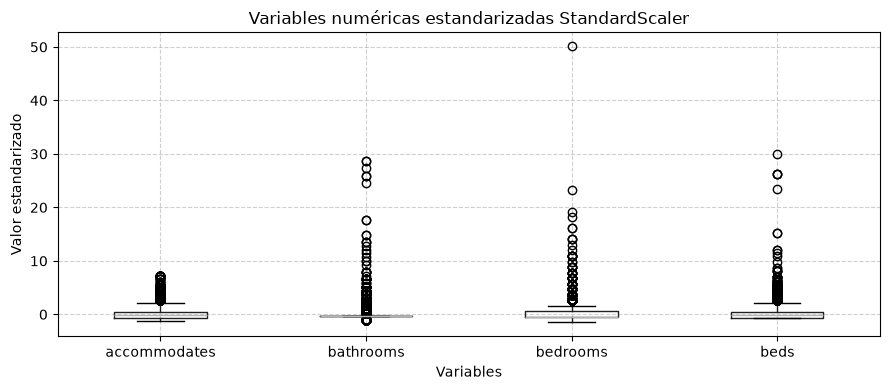

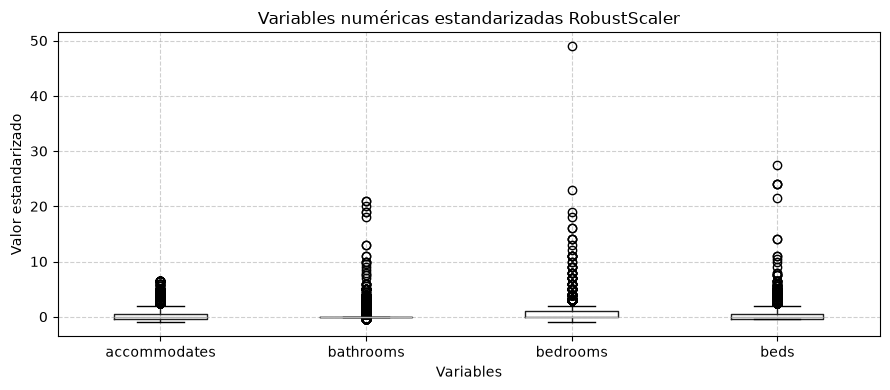

In [4]:
import matplotlib.pyplot as plt

# 3.1. Variables explicativas a visualizar
cols_num = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

# 3.2. Generación del gráfico de caja (Boxplot)
plt.figure(figsize=(9, 4))
df_decision_standard[cols_num].boxplot()

plt.title("Variables numéricas estandarizadas StandardScaler")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variables")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
# 3.2.1. Generación del gráfico de caja (Boxplot)
plt.figure(figsize=(9, 4))
df_decision_robust[cols_num].boxplot()

plt.title("Variables numéricas estandarizadas RobustScaler")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variables")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Decisión de escalamiento

Se mantiene `RobustScaler` como estrategia de escalamiento del pipeline. La comparación con `StandardScaler` permite evaluar una alternativa menos sensible a valores extremos, mientras que el patrón Strategy implementado permite cambiar el método de escalamiento sin modificar la estructura del pipeline.

Para la transformación y preparación de las variables numéricas se utilizan herramientas de scikit-learn, biblioteca de Python ampliamente utilizada para tareas de preprocesamiento y aprendizaje automático (Pedregosa et al., 2011).

In [5]:
# 4. DEFINICIÓN Y EJECUCIÓN DE PIPELINE POO DE TRANSFORMACIÓN
pasos_pipeline = [
    # Codificación de variables categóricas
    CodificadorNominal(columna='property_type', prefijo='propiedad'),
    CodificadorNominal(columna='neighbourhood_cleansed', prefijo='comuna'),
    CodificadorNominal(columna='room_type', prefijo='habitacion'),
    
    # Escalamiento de variables explicativas numéricas con el patrón Strategy
    EscaladorFlexible(
        columnas=[
            'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'hosts_time_as_host_years', 'number_of_reviews',
            'review_scores_rating', 'review_scores_accuracy',
            'review_scores_cleanliness', 'review_scores_checkin',
            'review_scores_communication', 'review_scores_location',
            'review_scores_value'
        ],
        estrategia=EstrategiaRobust()
    )
]

# Crear y ejecutar el Pipeline
pipeline = Pipeline(pasos=pasos_pipeline)
df_transformado = pipeline.ejecutar(df_limpio)

print("✓ Transformación POO ejecutada con éxito.")
print(f"Dimensiones finales de la matriz: {df_transformado.shape}")
df_transformado.head()

✓ Transformación POO ejecutada con éxito.
Dimensiones finales de la matriz: (17687, 114)


,hosts_time_as_host_years,accommodates,bathrooms,bedrooms,beds,price_quote_price_per_night,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,comuna_Renca,comuna_San_Joaquín,comuna_San_Miguel,comuna_Santiago,comuna_Vitacura,comuna_Ñuñoa,habitacion_Entire_home_apt,habitacion_Hotel_room,habitacion_Private_room,habitacion_Shared_room
0,1.000000,-0.5,0.0,0.0,-0.5,45647.0,-0.255814,0.631579,0.5625,0.636364,...,0,0,0,0,0,1,0,0,1,0
1,-0.500000,-1.0,0.0,0.0,-0.5,19856.0,-0.116279,0.631579,0.5625,0.636364,...,0,0,0,0,0,0,0,0,1,0
2,0.500000,0.0,0.0,0.0,0.0,46776.0,2.627907,-0.736842,-0.4375,-0.045455,...,0,0,0,0,0,0,1,0,0,0
3,-0.333333,-1.0,0.0,0.0,-0.5,25572.0,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.0,1.0,0.0,107043.5,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,1,0,0,0


## 3.1 Validación del pipeline

En esta sección se valida el resultado obtenido por el pipeline de la Fase 3.

La lógica de validación se encuentra implementada en `src/validacion.py`.
El notebook únicamente carga el conjunto de referencia de la Fase 2 y
ejecuta las validaciones correspondientes.

Se comprueba:

- ausencia de valores nulos;
- ausencia de variables categóricas sin codificar;
- equivalencia de dimensiones con el conjunto procesado de la Fase 2;
- equivalencia de las variables, considerando la normalización de nombres
  implementada en Fase 3;
- equivalencia de los valores procesados.

In [6]:
from src.validacion import Validacion
# Dataset procesado obtenido en la Fase 2
ruta_fase2 = "../../Data/Processed/airbnb_procesado.csv"

df_fase2 = pd.read_csv(ruta_fase2)

validador = Validacion(df_transformado)
validador.validar()

validador.comparar_con_fase2(df_fase2)

Nulos totales: 0
Columnas de texto sin codificar: ninguna
Dimensiones finales: (17687, 114)
✓ Las dimensiones coinciden: (17687, 114)
✓ Las variables de Fase 2 y Fase 3 son equivalentes.
✓ Los valores procesados coinciden con los obtenidos en Fase 2.
✓ La reorganización del código mediante POO no alteró el resultado del procesamiento.


True

#### Consideración sobre los nombres de las variables

Durante la Fase 3 se decidió normalizar los nombres de las variables
generadas mediante One-Hot Encoding para mantener una nomenclatura más
consistente.

Por este motivo, la validación genera una representación temporal de los
nombres de las columnas para poder comparar Fase 2 y Fase 3.

Esta normalización se realiza únicamente durante la validación y no modifica
los DataFrames originales.

### 3.1.1 Pruebas de casos límite y excepciones

Además de validar el conjunto procesado completo, se realizan pruebas
controladas para comprobar el comportamiento de la clase `Validacion`
ante entradas inválidas o situaciones límite.

Estas pruebas permiten verificar que el sistema detecte correctamente:

- objetos que no sean DataFrame
- DataFrames vacíos
- valores nulos
- modificaciones inesperadas respecto del resultado de Fase 2.

##### Prueba 1: Entrada que no sea un data frame

In [7]:
try:
    Validacion([1, 2, 3])

    assert False, (
        "La prueba debía generar TypeError."
    )

except TypeError:
    print(
        "Excepción controlada: "
        "se rechazó una entrada que no es DataFrame."
    )

Excepción controlada: se rechazó una entrada que no es DataFrame.


##### Prueba 2: Dataframe Vacío

In [8]:
df_vacio = pd.DataFrame() #Creamos un dataframe vacío para poner aprueba la clase Validacion

try:
    Validacion(df_vacio).validar()

    assert False, (
        "La prueba debía detectar el DataFrame vacío."
    )

except AssertionError:
    print(
        "Caso límite detectado: "
        "el DataFrame vacío fue rechazado."
    )

Caso límite detectado: el DataFrame vacío fue rechazado.


##### Prueba 3: DataFrame con valores nulos

In [9]:
df_con_nulos = pd.DataFrame({
    "variable_1": [1, 2, np.nan], # Agregamos valores nulos 
    "variable_2": [4, 5, 6]
})

try:
    Validacion(df_con_nulos).validar()

    assert False, (
        "La prueba debía detectar valores nulos."
    )

except AssertionError:
    print(
        "✓ Caso límite detectado: "
        "la validación encontró valores nulos."
    )

Nulos totales: 1
Columnas de texto sin codificar: ninguna
Dimensiones finales: (3, 2)
✓ Caso límite detectado: la validación encontró valores nulos.


#### Prueba 4: comprobar que la comparación detecte un cambio

In [10]:
df_fase2 = pd.read_csv("../../Data/Processed/airbnb_procesado.csv")
validador = Validacion(df_transformado)
validador.comparar_con_fase2(df_fase2)
df_fase2_alterado = df_fase2.copy()
df_fase2_alterado.iloc[0, 0] = (
    df_fase2_alterado.iloc[0, 0] + 100  #cambia intencionalmente un valor
)
try:
    validador.comparar_con_fase2(
        df_fase2_alterado
    )

    assert False, (
        "La comparación debía detectar "
        "la modificación de los datos."
    )

except AssertionError:
    print(
        
        "se detectó una modificación "
        "respecto de Fase 2."
    )

✓ Las dimensiones coinciden: (17687, 114)
✓ Las variables de Fase 2 y Fase 3 son equivalentes.
✓ Los valores procesados coinciden con los obtenidos en Fase 2.
✓ La reorganización del código mediante POO no alteró el resultado del procesamiento.
✓ Las dimensiones coinciden: (17687, 114)
✓ Las variables de Fase 2 y Fase 3 son equivalentes.
se detectó una modificación respecto de Fase 2.


In [11]:
# Traducción del notebook original aplicada a la copia interpretable.
# El pipeline de src/ sigue utilizando los nombres originales del archivo.
traduccion_columnas = {
    "hosts_time_as_host_years": "años_como_anfitrion",
    "neighbourhood_cleansed": "comuna",
    "property_type": "tipo_propiedad",
    "room_type": "tipo_habitacion",
    "accommodates": "capacidad_personas",
    "bathrooms": "baños",
    "bedrooms": "dormitorios",
    "beds": "camas",
    "number_of_reviews": "numero_evaluaciones",
    "review_scores_rating": "puntaje_general",
    "review_scores_accuracy": "puntaje_precision",
    "review_scores_cleanliness": "puntaje_limpieza",
    "review_scores_checkin": "puntaje_llegada",
    "review_scores_communication": "puntaje_comunicacion",
    "review_scores_location": "puntaje_ubicacion",
    "review_scores_value": "puntaje_calidad_precio",
    "price_quote_price_per_night": "precio_por_noche",
}
traduccion_habitaciones = {
    "Entire home/apt": "Alojamiento completo",
    "Private room": "Habitación privada",
    "Shared room": "Habitación compartida",
    "Hotel room": "Habitación de hotel",
}

df_analisis = df_analisis.rename(columns=traduccion_columnas).copy()
df_analisis["tipo_habitacion"] = df_analisis["tipo_habitacion"].replace(traduccion_habitaciones)
display(df_analisis[["comuna", "tipo_propiedad", "tipo_habitacion", "precio_por_noche"]].head())

,comuna,tipo_propiedad,tipo_habitacion,precio_por_noche
0,Ñuñoa,Private room in home,Habitación privada,45647.0
1,Recoleta,Private room in condo,Habitación privada,19856.0
2,Recoleta,Entire rental unit,Alojamiento completo,46776.0
3,Recoleta,Private room in rental unit,Habitación privada,25572.0
4,Recoleta,Entire rental unit,Alojamiento completo,107043.5


In [12]:
# Comprobación de que no quedan valores nulos tras el pipeline
assert df_transformado.isnull().sum().sum() == 0, "Error: Existen nulos residuales."

# Comprobación de que la columna objetivo no fue alterada ni escalada
assert "price_quote_price_per_night" in df_transformado.columns, "Error: Se perdió el precio."

print("✓ Validación técnica exitosa: Matriz libre de nulos y precio preservado.")

✓ Validación técnica exitosa: Matriz libre de nulos y precio preservado.


In [13]:
# La tabla transformada final vive en prep.df
print("Dimensiones finales:", df_transformado.shape)
df_transformado.head()



Dimensiones finales: (17687, 114)


,hosts_time_as_host_years,accommodates,bathrooms,bedrooms,beds,price_quote_price_per_night,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,comuna_Renca,comuna_San_Joaquín,comuna_San_Miguel,comuna_Santiago,comuna_Vitacura,comuna_Ñuñoa,habitacion_Entire_home_apt,habitacion_Hotel_room,habitacion_Private_room,habitacion_Shared_room
0,1.000000,-0.5,0.0,0.0,-0.5,45647.0,-0.255814,0.631579,0.5625,0.636364,...,0,0,0,0,0,1,0,0,1,0
1,-0.500000,-1.0,0.0,0.0,-0.5,19856.0,-0.116279,0.631579,0.5625,0.636364,...,0,0,0,0,0,0,0,0,1,0
2,0.500000,0.0,0.0,0.0,0.0,46776.0,2.627907,-0.736842,-0.4375,-0.045455,...,0,0,0,0,0,0,1,0,0,0
3,-0.333333,-1.0,0.0,0.0,-0.5,25572.0,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.0,1.0,0.0,107043.5,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,1,0,0,0


### 3.2 Verificación de variables numéricas escaladas

El gráfico de cajas muestra capacidad de personas, baños, dormitorios y camas después de aplicar RobustScaler.

Este método resta la mediana y divide por una escala basada en el rango intercuartílico. Por tanto, cero representa el centro definido por la mediana del conjunto utilizado para ajustar el escalador, no su promedio.

El escalamiento permite expresar las variables en escalas comparables, pero no elimina valores extremos ni transforma necesariamente sus distribuciones en normales. Los valores alejados de cero deben revisarse en sus unidades originales antes de interpretarlos como errores.

El boxplot es un control descriptivo del preprocesamiento; las comprobaciones programáticas complementan esta inspección visual.

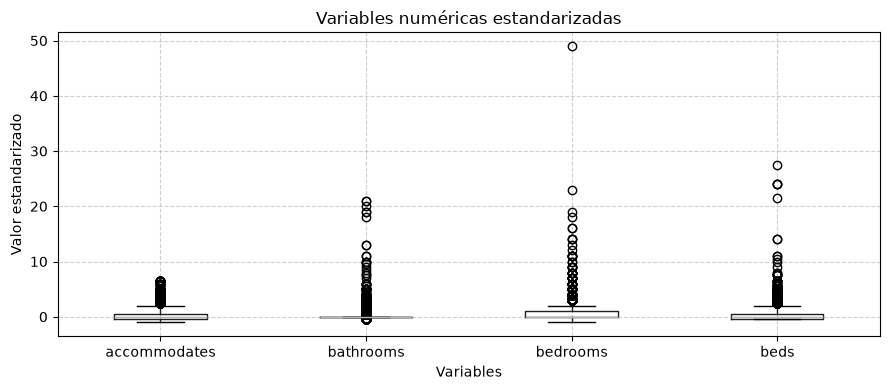

In [14]:
import matplotlib.pyplot as plt

# 1. Variables explicativas a visualizar
cols_num = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

# 2. Generación del gráfico de caja (Boxplot)
plt.figure(figsize=(9, 4))
df_transformado[cols_num].boxplot()

plt.title("Variables numéricas estandarizadas")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variables")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Interpretación del gráfico: El boxplot muestra que las variables estandarizadas se concentran principalmente alrededor de cero, lo que es consistente con el proceso de estandarización aplicado. Sin embargo, se observa una importante presencia de valores atípicos positivos, especialmente en las variables baños, dormitorios y camas. Destaca dormitorios, que presenta un valor extremadamente alejado del resto de las observaciones. Estos valores no deben considerarse automáticamente errores, ya que podrían corresponder a alojamientos reales con características poco frecuentes; sin embargo, resulta recomendable identificarlos y revisar su consistencia antes de utilizarlos en análisis posteriores.

### 4.1. Vinculación directa con la pregunta del informe

La programación orientada a objetos organiza el procesamiento de los datos, mientras que la copia interpretable `df_analisis` permite responder la pregunta de investigación: **¿Qué características observables de los alojamientos se relacionan con las diferencias de precio?**

Esta copia conserva la comuna, el tipo de propiedad y el tipo de habitación como categorías legibles, junto con las variables numéricas en sus unidades originales y el precio por noche en CLP. Se utiliza para comparar precios entre grupos y explorar asociaciones con las características de los alojamientos.

Se presentan la mediana y el promedio para distinguir el precio central de cada grupo del efecto de valores extremos. El análisis es descriptivo y exploratorio: identifica diferencias y asociaciones observadas, pero no demuestra relaciones causales.

In [15]:
# 4.1 Análisis del precio por comuna y tipo de habitación

base = df_analisis.copy()

# Definición dinámica de columnas seguras
col_comuna = "neighbourhood_cleansed" if "neighbourhood_cleansed" in base.columns else "comuna"
col_habitacion = "room_type" if "room_type" in base.columns else "tipo_habitacion"
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in base.columns else "precio_por_noche"

# 1. Análisis por comuna (10 con menor mediana)
por_comuna = (
    base.groupby(col_comuna)[col_precio]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana", ascending=True)
    .head(10)
)

# 2. Análisis por tipo de habitación
por_habitacion = (
    base.groupby(col_habitacion)[col_precio]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana", ascending=False)
)

# Imprimir resultados formateados
print("10 comunas con menor mediana de precio por noche:")
display(por_comuna.round(0).astype(int))

print("\nPrecio por tipo de habitación:")
display(por_habitacion.round(0).astype(int))

10 comunas con menor mediana de precio por noche:


,alojamientos,mediana,promedio
comuna,,,
Pedro Aguirre Cerda,5,25051,39829
Renca,33,29440,54003
Lo Prado,16,29882,43603
El Bosque,8,33882,41610
Quilicura,30,36614,53424
Cerro Navia,3,36992,43801
Quinta Normal,54,37227,38280
Estación Central,429,39941,46964
Maipú,87,40485,48321



Precio por tipo de habitación:


,alojamientos,mediana,promedio
tipo_habitacion,,,
Habitación de hotel,56,117138,162430
Alojamiento completo,14424,64900,122687
Habitación privada,3148,34235,98419
Habitación compartida,59,20541,34104


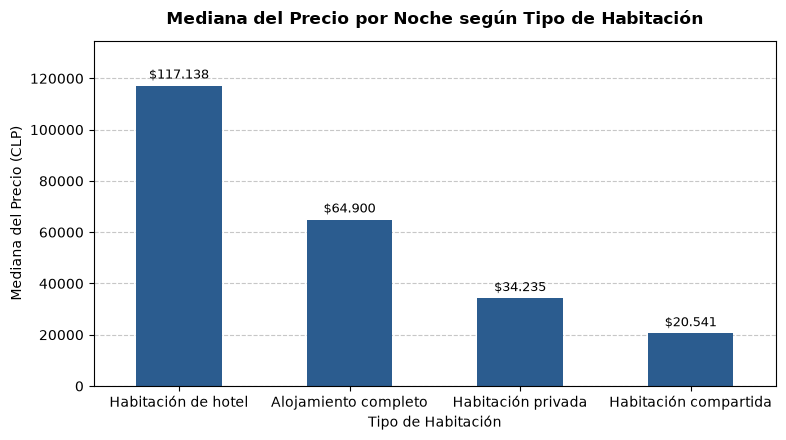

In [16]:
# Comparación visual de la mediana del precio por tipo de habitación

col_habitacion = "room_type" if "room_type" in df_analisis.columns else "tipo_habitacion"
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in df_analisis.columns else "precio_por_noche"

mediana_habitacion = (
    df_analisis
    .groupby(col_habitacion)[col_precio]
    .median()
    .sort_values(ascending=False)
)

# Renderizado de gráfico
ax = mediana_habitacion.plot(kind="bar", figsize=(8, 4.5), color="#2b5c8f", zorder=2)

# Estética y formato
plt.title("Mediana del Precio por Noche según Tipo de Habitación", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Tipo de Habitación", fontsize=10)
plt.ylabel("Mediana del Precio (CLP)", fontsize=10)
plt.xticks(rotation=0, ha="center") # Si las etiquetas son cortas, 0° suele leerse mejor
plt.grid(axis="y", linestyle="--", alpha=0.7, zorder=1)

# Agregar etiquetas de valor sobre cada barra
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.0f}".replace(",", "."), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha="center", va="bottom", 
        fontsize=9, xytext=(0, 3), 
        textcoords="offset points"
    )

# Ajuste de límites para que no se corte el texto de la barra más alta
ax.set_ylim(0, mediana_habitacion.max() * 1.15)

plt.tight_layout()
plt.show()

## 5. Herencia: reutilizar y especializar

La **herencia** permite crear una clase hija a partir de una clase base. En nuestro proyecto podemos comparar dos estrategias de tratamiento de nulos: eliminar filas o imputar la mediana. El ejemplo se mantiene pequeño para mostrar el concepto sin alterar el dataset principal.


In [17]:
class Limpiador:
    """Clase base: realiza limpieza básica comun (validación y duplicados) y eliminación de nulos."""
    def limpiar(self, df):
        df = df.copy()
        df = df.drop_duplicates()  # Lógica común reutilizable
        return df.dropna()

class LimpiadorPorMediana(Limpiador):
    """Clase hija: hereda la limpieza base y especializa el tratamiento de nulos mediante mediana."""
    def limpiar(self, df):
        # 1. Reutiliza la limpieza común de la clase padre
        df = df.copy()
        df = df.drop_duplicates()
        
        # 2. Especializa: imputa en lugar de eliminar
        for columna in df.select_dtypes(include="number").columns:
            df[columna] = df[columna].fillna(df[columna].median())
        return df
# Ejemplo simple inspirado en variables del proyecto Airbnb
mini = pd.DataFrame({
    "precio": [35000.0, np.nan, 52000.0],
    "capacidad_personas": [1.0, 2.0, np.nan]
})
print("Tabla original:", mini.shape)
print("Limpiador base:", Limpiador().limpiar(mini).shape)
resultado_mediana = LimpiadorPorMediana().limpiar(mini)
print("LimpiadorPorMediana:", resultado_mediana.shape,
      "->", int(resultado_mediana.isna().sum().sum()), "nulos")
resultado_mediana


Tabla original: (3, 2)
Limpiador base: (1, 2)
LimpiadorPorMediana: (3, 2) -> 0 nulos


,precio,capacidad_personas
0,35000.0,1.0
1,43500.0,2.0
2,52000.0,1.5


## Programación orientada a objetos en el procesamiento real

| Principio | Implementación | Evidencia |
|---|---|---|
| Herencia | `CodificadorNominal` y `EscaladorFlexible` heredan de `Transformador`. | Implementan `ajustar()` y `transformar()` según su responsabilidad. |
| Polimorfismo | `Pipeline.ejecutar()` recorre los transformadores mediante una interfaz común. | Ejecuta `paso.ajustar(df).transformar(df)` sin distinguir el tipo de cada paso. |
| Encapsulamiento | `LimpiadorAirbnb` conserva medianas internas y las expone mediante una propiedad que devuelve una copia. Los transformadores controlan el estado de ajuste. | Las pruebas verifican copia defensiva y rechazo de operaciones realizadas antes del ajuste. |
| Cohesión | Los módulos separan carga, limpieza, transformación y validación. | Cada componente atiende una responsabilidad delimitada. |
| Bajo acoplamiento | El orquestador utiliza el contrato de los transformadores. | La estrategia de escalamiento se selecciona al construir el escalador. |

La limpieza de esta ejecución utiliza `LimpiadorAirbnb` antes del pipeline de codificación y escalamiento. Aunque `ImputadorMediana` existe en el módulo de transformación, no se presenta como un paso utilizado en este flujo.

### Patrón Strategy

**Problema:** el escalamiento debe permitir comparar y seleccionar métodos distintos sin introducir decisiones específicas dentro del orquestador.

**Solución:** `EscaladorFlexible` recibe una estrategia. `EstrategiaStandard` utiliza media y desviación estándar; `EstrategiaRobust` utiliza mediana y rango intercuartílico.

**Consecuencia:** el método puede cambiarse al configurar el objeto, sin modificar el ciclo del pipeline. Sin esta separación, el escalador o el orquestador tendría que incorporar condiciones específicas para cada alternativa.

La elección de RobustScaler corresponde a una decisión de preprocesamiento. Los gráficos finales utilizan `df_analisis`, que conserva las unidades originales; por ello, sus hallazgos no dependen directamente de graficar los valores escalados.

## 6. Recursividad

En Fase 2 utilizamos `aplanar` para convertir un diccionario de metadatos
anidado en una tabla de pares clave–valor. En Fase 3 conservamos esa función,
pero registramos las dimensiones y los pasos del pipeline POO ejecutado.

Cuando un valor es otro diccionario, la función se llama a sí misma y continúa
construyendo la ruta de claves (caso recursivo). Cuando encuentra un valor
simple o una lista, lo incorpora al resultado (caso base). La recursión se
aplica a los metadatos del proyecto, no a las filas de precios.


Los metadatos distinguen la entrada original `Data/Raw/listings.csv.gz` de la salida transformada `Data/Processed/airbnb_f3_poo_transformado.csv`. Las dimensiones de entrada corresponden a `df_raw`, las de la base limpia a `df_limpio` y las de la matriz transformada a `df_transformado`.

La tabla obtenida mediante `aplanar` se exporta en `docs/metadatos_pipeline_f3.csv`, dejando un registro de las dimensiones y los componentes utilizados en el procesamiento.

In [18]:
METADATOS_F3 = {
    "proyecto": {
        "nombre": "Airbnb Santiago",
        "fase": "F3",
    },
    "datos": {
        "archivo": os.path.basename(RUTA_DATOS),
        "entrada": {
            "filas": len(df_raw),
            "columnas": df_raw.shape[1],
        },
        "base_limpia": {
            "filas": len(df_limpio),
            "columnas": df_limpio.shape[1],
        },
        "matriz_transformada": {
            "filas": len(df_transformado),
            "columnas": df_transformado.shape[1],
        },
    },
    "pipeline": {
        "limpieza": type(limpiador).__name__,
        "pasos": [type(paso).__name__ for paso in pasos_pipeline],
        "escalamiento": "EstrategiaRobust",
        "objetivo": "price_quote_price_per_night",
    },
}


def aplanar(estructura, prefijo="", separador="."):
    """Convierte un diccionario anidado en pares clave–valor."""
    plano = {}

    for clave, valor in estructura.items():
        ruta = f"{prefijo}{separador}{clave}" if prefijo else str(clave)

        if isinstance(valor, dict):
            # Caso recursivo: seguimos dentro del diccionario.
            plano.update(aplanar(valor, ruta, separador))
        elif isinstance(valor, (list, tuple)):
            # Caso base: dejamos la secuencia como texto para la tabla.
            plano[ruta] = ", ".join(str(item) for item in valor)
        else:
            # Caso base: guardamos el valor simple.
            plano[ruta] = valor

    return plano


metadatos_planos = aplanar(METADATOS_F3)

tabla_metadatos = pd.DataFrame(
    metadatos_planos.items(),
    columns=["clave", "valor"],
)

display(tabla_metadatos)

,clave,valor
0,proyecto.nombre,Airbnb Santiago
1,proyecto.fase,F3
2,datos.archivo,airbnb_f4.csv
3,datos.entrada.filas,18534
4,datos.entrada.columnas,90
5,datos.base_limpia.filas,17687
6,datos.base_limpia.columnas,17
7,datos.matriz_transformada.filas,17687
8,datos.matriz_transformada.columnas,114
9,pipeline.limpieza,LimpiadorAirbnb


In [19]:
from pathlib import Path

raiz_proyecto = Path(RUTA_DATOS).resolve().parents[2]
ruta_salida = raiz_proyecto / "docs" / "metadatos_pipeline_f3.csv"

ruta_salida.parent.mkdir(parents=True, exist_ok=True)
tabla_metadatos.to_csv(ruta_salida, index=False)

print(f"Metadatos verificados y exportados en: {ruta_salida}")

Metadatos verificados y exportados en: C:\Users\alfre\proyecto-grupo3-mcdi500\docs\metadatos_pipeline_f3.csv


## 7. Eficiencia: bucle vs. operación vectorizada

Para que el ejemplo se relacione con Airbnb, compararemos dos formas de calcular el **precio total** de todos los alojamientos del dataset: un bucle de Python y la suma vectorizada de pandas/NumPy.


In [20]:
import timeit
import tracemalloc
import numpy as np
import pandas as pd

# 1. Definición defensiva de la columna de precio
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in df_analisis.columns else "precio_por_noche"

# 2. Extracción descartando valores nulos para evitar NaN en los cálculos
precios_total = df_analisis[col_precio].dropna().to_numpy()
REPETICIONES = 1

def con_bucle(valores):
    total = 0.0
    for precio in valores:
        total += precio
    return total

def vectorizado(valores):
    return float(valores.sum())

def medir(funcion, valores):
    # Tiempo: 100 ejecuciones sin seguimiento de memoria
    tiempo_total = timeit.timeit(
        lambda: funcion(valores),
        number=REPETICIONES
    )

    # Memoria: una ejecución independiente
    tracemalloc.start()
    try:
        funcion(valores)
        _, pico_bytes = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()

    return tiempo_total, pico_bytes

filas = []

for n in (1000, 5000, len(precios_total)):
    valores = precios_total[:n]

    # Verificar equivalencia antes de comparar rendimiento
    assert np.isclose(con_bucle(valores), vectorizado(valores)), "Error: Los resultados entre bucle y NumPy no coinciden."

    for nombre, funcion in (("Bucle", con_bucle), ("NumPy", vectorizado)):
        tiempo_total, pico_bytes = medir(funcion, valores)

        filas.append({
            "registros": n,
            "método": nombre,
            "tiempo_total_s": tiempo_total,
            "promedio_por_ejecucion_ms": tiempo_total / REPETICIONES * 1000,
            "pico_memoria_python_kib": pico_bytes / 1024,
        })

mediciones = pd.DataFrame(filas)
display(mediciones)

print(f"Suma de precios (CLP): ${vectorizado(precios_total):,.0f}")

,registros,método,tiempo_total_s,promedio_por_ejecucion_ms,pico_memoria_python_kib
0,1000,Bucle,0.000226,0.2264,0.284180
1,1000,NumPy,0.000021,0.0214,0.125000
2,5000,Bucle,0.000847,0.8465,0.284180
3,5000,NumPy,0.000063,0.0626,0.125000
4,17687,Bucle,0.002979,2.9793,0.859375
5,17687,NumPy,0.000033,0.0334,0.125000


Suma de precios (CLP): $2,090,563,484


In [21]:
import timeit
import tracemalloc
import numpy as np
import pandas as pd

# 1. Definición defensiva de la columna de precio
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in df_analisis.columns else "precio_por_noche"

# 2. Extracción descartando valores nulos para evitar NaN en los cálculos
precios_total = df_analisis[col_precio].dropna().to_numpy()
REPETICIONES = 100

def con_bucle(valores):
    total = 0.0
    for precio in valores:
        total += precio
    return total

def vectorizado(valores):
    return float(valores.sum())

def medir(funcion, valores):
    # Tiempo: 100 ejecuciones sin seguimiento de memoria
    tiempo_total = timeit.timeit(
        lambda: funcion(valores),
        number=REPETICIONES
    )

    # Memoria: una ejecución independiente
    tracemalloc.start()
    try:
        funcion(valores)
        _, pico_bytes = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()

    return tiempo_total, pico_bytes

filas = []

for n in (1000, 5000, len(precios_total)):
    valores = precios_total[:n]

    # Verificar equivalencia antes de comparar rendimiento
    assert np.isclose(con_bucle(valores), vectorizado(valores)), "Error: Los resultados entre bucle y NumPy no coinciden."

    for nombre, funcion in (("Bucle", con_bucle), ("NumPy", vectorizado)):
        tiempo_total, pico_bytes = medir(funcion, valores)

        filas.append({
            "registros": n,
            "método": nombre,
            "tiempo_total_100_s": tiempo_total,
            "promedio_por_ejecucion_ms": tiempo_total / REPETICIONES * 1000,
            "pico_memoria_python_kib": pico_bytes / 1024,
        })

mediciones = pd.DataFrame(filas)
display(mediciones)

print(f"Suma de precios (CLP): ${vectorizado(precios_total):,.0f}")

,registros,método,tiempo_total_100_s,promedio_por_ejecucion_ms,pico_memoria_python_kib
0,1000,Bucle,0.011099,0.110990,0.28418
1,1000,NumPy,0.000529,0.005286,0.12500
2,5000,Bucle,0.060209,0.602089,0.28418
3,5000,NumPy,0.000257,0.002574,0.12500
4,17687,Bucle,0.169241,1.692410,0.28418
5,17687,NumPy,0.000609,0.006087,0.12500


Suma de precios (CLP): $2,090,563,484


### Interpretación del rendimiento y elección de implementación

Ambas implementaciones calculan la suma de los mismos valores y se comprueba su equivalencia numérica antes de medir. El tiempo total corresponde a 100 ejecuciones y el promedio se obtiene dividiéndolo por 100.

Ambas sumas tienen complejidad temporal O(n), porque deben recorrer los elementos. NumPy reduce el costo del recorrido mediante una implementación compilada. La ventaja observada depende del tamaño, del tipo de datos y del entorno; no constituye una aceleración universal.

El arreglo de entrada requiere memoria O(n) y se crea antes de medir. Las implementaciones no construyen explícitamente otra colección proporcional al tamaño de entrada, por lo que su espacio auxiliar es constante para este caso.

`tracemalloc` registra las asignaciones rastreadas durante una ejecución independiente. Su pico no representa toda la memoria del proceso ni incluye el arreglo creado antes de iniciar el seguimiento. `nbytes` informa los bytes ocupados por los datos del arreglo y se reporta por separado; no debe sumarse mecánicamente al pico para estimar la memoria total.

Se prefiere la suma vectorizada para los arreglos numéricos del proyecto por su claridad y por el rendimiento obtenido. La suma de precios es un agregado descriptivo de los valores publicados, no una estimación de ingresos.

### Límites del benchmark

Se comparan prefijos del mismo arreglo, lo que mantiene constantes el tipo de datos y el procedimiento de selección. Los resultados pueden variar por carga del equipo y costos de preparación. Las mediciones no incluyen carga desde disco, limpieza ni construcción inicial del arreglo y, por tanto, no representan el tiempo del pipeline completo.

## 8. Aplicación al proyecto Airbnb Santiago

1. **Entrada:** el módulo de carga lee el archivo original `Data/Raw/listings.csv.gz`.

2. **Preparación y limpieza:** `preparar_filas()` selecciona las variables de estudio y prepara los registros utilizables. `LimpiadorAirbnb` aprende las medianas durante el ajuste y las aplica para imputar las variables numéricas correspondientes, excluyendo el precio.

3. **Transformación mediante POO:** `Pipeline` coordina los objetos `CodificadorNominal` y `EscaladorFlexible` mediante una interfaz común. Esta organización integra herencia, polimorfismo y separación de responsabilidades.

4. **Variables categóricas:** comuna, tipo de propiedad y tipo de habitación se transforman mediante One-Hot Encoding.

5. **Variables numéricas:** las trece variables explicativas se escalan con `EstrategiaRobust`. El precio por noche se conserva en CLP.

6. **Base interpretable:** `df_analisis` conserva las categorías y las unidades originales. Sus nombres se traducen para facilitar la comunicación de resultados.

7. **Validación:** `Validacion` comprueba la matriz resultante y la compara con el conjunto procesado de la Fase 2. Se incluyen pruebas controladas de entradas inválidas y modificaciones de los datos.

8. **Recursividad:** `aplanar` convierte los metadatos anidados del procesamiento en una tabla de pares clave–valor.

9. **Eficiencia:** se comparan una suma mediante bucle y una suma vectorizada con NumPy, verificando primero su equivalencia y midiendo tiempo y memoria en tamaños crecientes.

10. **Resultados:** se exporta la matriz transformada y se elaboran visualizaciones vinculadas con la pregunta de investigación.

### 8.1. Exportación opcional del dataset transformado

La matriz transformada puede guardarse como salida de Fase 3. Esta exportación no reemplaza la copia interpretable usada para responder la pregunta del informe.


In [22]:
from pathlib import Path

# Definimos la ruta usando pathlib
RUTA_SALIDA = Path("../../Data/Processed/airbnb_f3_poo_transformado.csv")

# Creamos las carpetas si no existen
RUTA_SALIDA.parent.mkdir(parents=True, exist_ok=True)

# Exportamos el DataFrame a CSV
df_transformado.to_csv(RUTA_SALIDA, index=False)

print(f"✓ Archivo exportado: {RUTA_SALIDA.name}")
print(f"✓ Dimensiones finales: {df_transformado.shape}")

✓ Archivo exportado: airbnb_f3_poo_transformado.csv
✓ Dimensiones finales: (17687, 114)


## 9. Gráficos

## Visualizaciones dirigidas por los objetivos

Se conserva `df_analisis` antes de codificar y escalar para visualizar categorías legibles y variables en sus unidades originales. No es necesario invertir el escalamiento como en el ejemplo del profesor, porque esta copia mantiene la información interpretable.

| Visualización | Objetivo | Justificación |
|---|---|---|
| Cantidad de anuncios por comuna | 1 | Muestra la desigual representación territorial y contextualiza las comparaciones posteriores. |
| Violín del precio por habitación | 1 | Compara la forma de las distribuciones y sus medianas. |
| Mapa de calor por comuna y habitación | 1 | Compara precios entre comunas dentro de dos tipos de habitación. |
| Mediana y percentiles por capacidad | 2 | Resume el precio central y su dispersión para cada capacidad. |
| Mapa de calor por comuna y capacidad | 1 y 2 | Permite observar conjuntamente ubicación y capacidad. |
| Correlación con el precio | 3 | Resume asociaciones monotónicas entre variables numéricas y precio. |

Las escalas logarítmicas permiten representar precios con amplitud considerable sin eliminar valores altos. Los mapas seleccionan comunas por cantidad de observaciones y muestran el tamaño de cada grupo.

Spearman se utiliza para estudiar asociaciones monotónicas sin exigir una relación lineal. Sus coeficientes no representan efectos causales ni contribuciones independientes al precio.

### Selección de figuras principales

Como núcleo del relato se seleccionan:

1. Mapa de calor por comuna y tipo de habitación: ubicación y tipo de alojamiento.
2. Mediana y dispersión por capacidad: tamaño de alojamiento.
3. Correlación con el precio: comparación de características numéricas.

El conteo de anuncios, el violín y el mapa por capacidad complementan y contextualizan esos resultados.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter, MaxNLocator

FUENTE = "Fuente: Inside Airbnb, Santiago. Elaboración propia."

datos_graficos = df_analisis.copy()

def buscar_columna(*alternativas):
    for columna in alternativas:
        if columna in datos_graficos.columns:
            return columna
    raise KeyError(
        f"No se encontró ninguna de estas columnas: {alternativas}"
    )

col_precio_g = buscar_columna(
    "precio_por_noche", "price_quote_price_per_night"
)
col_comuna_g = buscar_columna("comuna", "neighbourhood_cleansed")
col_tipo_g = buscar_columna("tipo_habitacion", "room_type")
col_capacidad_g = buscar_columna("capacidad_personas", "accommodates")

for columna in (col_precio_g, col_capacidad_g):
    datos_graficos[columna] = pd.to_numeric(
        datos_graficos[columna], errors="coerce"
    )

# Base para gráficos de precios: precios positivos y finitos.
base_precios = datos_graficos.loc[
    np.isfinite(datos_graficos[col_precio_g])
    & (datos_graficos[col_precio_g] > 0)
].copy()

print(
    "Registros excluidos por precio ausente, no finito o no positivo:",
    len(datos_graficos) - len(base_precios)
)

formato_clp = FuncFormatter(lambda valor, _: f"${valor:,.0f}")

def finalizar_figura(fig):
    # Detectamos etiquetas, títulos o anotaciones que contienen "n".
    textos = [texto.get_text() for texto in fig.texts]

    for ax in fig.axes:
        textos.extend(texto.get_text() for texto in ax.texts)
        textos.extend(texto.get_text() for texto in ax.get_xticklabels())
        textos.extend(texto.get_text() for texto in ax.get_yticklabels())
        textos.extend([
            ax.get_title(),
            ax.get_xlabel(),
            ax.get_ylabel(),
        ])

    incluye_n = any(
        "n=" in texto or "n =" in texto or "n <" in texto
        for texto in textos
    )

    if incluye_n:
        fig.text(
            0.01, 0.045,
            "n = número de observaciones",
            fontsize=9,
            color="#333333",
        )

    fig.text(
        0.01, 0.01,
        FUENTE,
        fontsize=8,
        color="#555555",
    )

    fig.tight_layout(rect=(0, 0.08 if incluye_n else 0.04, 1, 1))
    plt.show()

Registros excluidos por precio ausente, no finito o no positivo: 0


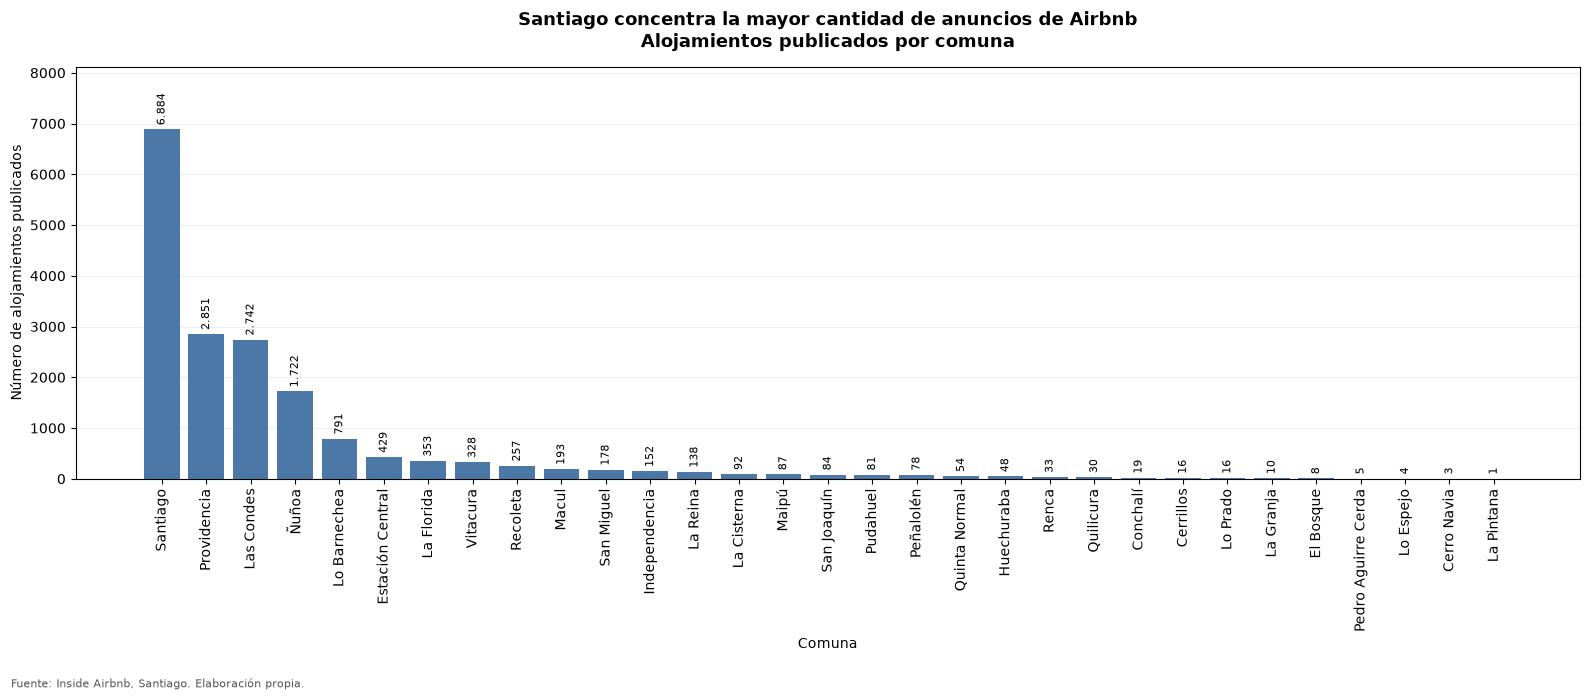

In [24]:
conteo_comunas = (
    datos_graficos[col_comuna_g]
    .dropna()
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 7))

barras = ax.bar(
    conteo_comunas.index,
    conteo_comunas.values,
    color="#4C78A8",
)

ax.bar_label(
    barras,
    labels=[f"{n:,}".replace(",", ".") for n in conteo_comunas.values],
    padding=3,
    fontsize=8,
    rotation=90,
)

ax.set_ylim(0, conteo_comunas.max() * 1.18)
ax.set_xlabel("Comuna")
ax.set_ylabel("Número de alojamientos publicados")
ax.set_title(
    "Santiago concentra la mayor cantidad de anuncios de Airbnb\n"
    "Alojamientos publicados por comuna",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.tick_params(axis="x", labelrotation=90)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

finalizar_figura(fig)

### Interpretación de la cantidad de alojamientos por comuna

La oferta registrada se concentra principalmente en **Santiago**, con 6.884 alojamientos, seguida de **Providencia** (2.851), **Las Condes** (2.742) y **Ñuñoa** (1.722). Las demás comunas presentan cantidades considerablemente menores, lo que evidencia una distribución desigual de los anuncios dentro del territorio analizado.

Esta diferencia debe considerarse al comparar precios: las estadísticas de comunas con pocos registros describen grupos pequeños y pueden cambiar considerablemente al incorporar nuevos alojamientos. El gráfico representa anuncios presentes en la base, no arriendos efectivamente realizados ni demanda turística.

Los mapas de calor posteriores seleccionan las diez comunas con más observaciones dentro del conjunto correspondiente a cada gráfico. Las visualizaciones por tipo de habitación, capacidad y correlación utilizan los registros válidos para sus respectivas variables, sin restringirse a esas diez comunas.

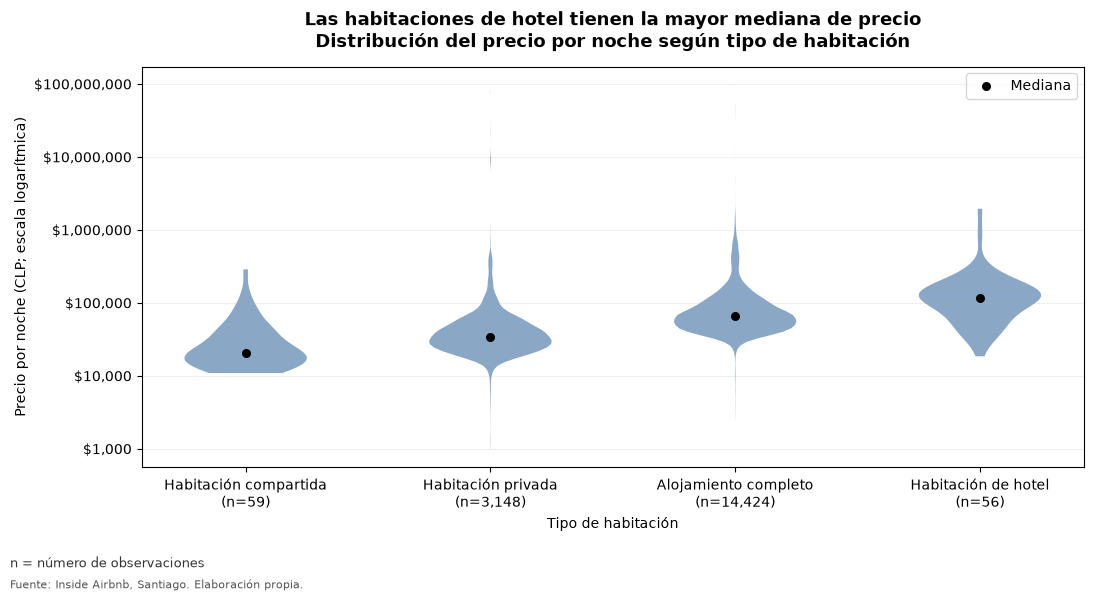

In [25]:
base_violin = base_precios.dropna(subset=[col_tipo_g])

orden_tipos = (
    base_violin.groupby(col_tipo_g)[col_precio_g]
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(11, 6))
etiquetas = []

for posicion, tipo in enumerate(orden_tipos, start=1):
    precios = base_violin.loc[
        base_violin[col_tipo_g] == tipo, col_precio_g
    ].to_numpy()

    etiquetas.append(f"{tipo}\n(n={len(precios):,})")

    if len(precios) >= 2 and np.unique(precios).size >= 2:
        partes = ax.violinplot(
            [np.log10(precios)],
            positions=[posicion],
            showextrema=False,
        )

        for cuerpo in partes["bodies"]:
            cuerpo.set_facecolor("#4C78A8")
            cuerpo.set_alpha(0.65)

    ax.scatter(
        posicion,
        np.log10(np.median(precios)),
        color="black",
        s=30,
        zorder=3,
        label="Mediana" if posicion == 1 else None,
    )

ax.set_xticks(range(1, len(orden_tipos) + 1))
ax.set_xticklabels(etiquetas)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda valor, _: f"${10 ** valor:,.0f}")
)
ax.set_xlabel("Tipo de habitación")
ax.set_ylabel("Precio por noche (CLP; escala logarítmica)")
ax.set_title(
    "Las habitaciones de hotel tienen la mayor mediana de precio\n"
    "Distribución del precio por noche según tipo de habitación",
    fontsize=13,
    fontweight="bold",
    pad=14,
)
ax.legend()
ax.grid(axis="y", alpha=0.2)

finalizar_figura(fig)

### Interpretación de la distribución del precio por tipo de habitación

Las **habitaciones compartidas** presentan la menor mediana del precio, seguidas de las **habitaciones privadas**, los **alojamientos completos** y las **habitaciones de hotel**. Este orden muestra una asociación entre el tipo de alojamiento y el precio por noche.

Los tamaños de los grupos son muy distintos: existen 14.424 alojamientos completos y 3.148 habitaciones privadas, frente a 59 habitaciones compartidas y 56 habitaciones de hotel. La escala logarítmica permite visualizar esta amplia variación de precios; el punto negro señala la mediana y el ancho del violín representa la concentración de observaciones dentro de cada categoría.

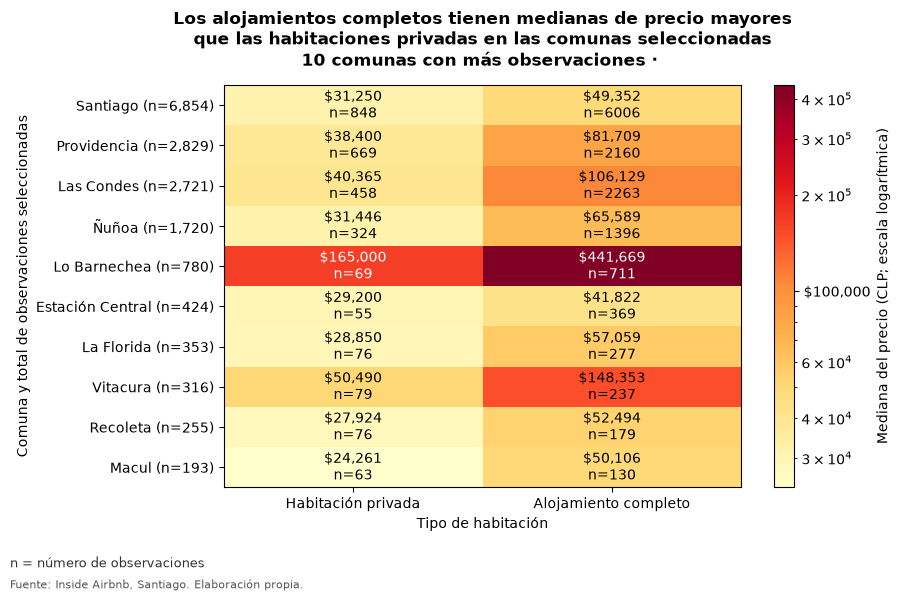

In [26]:
N_COMUNAS = 10

tipos_seleccionados = [
    "Habitación privada",
    "Alojamiento completo",
]

# Filtramos las dos categorías sobre la base con precios válidos.
base_mapa = base_precios.loc[
    base_precios[col_tipo_g].isin(tipos_seleccionados)
].dropna(subset=[col_comuna_g])

# Seleccionamos las comunas con más observaciones en esas categorías.
conteo_mapa = (
    base_mapa.groupby(col_comuna_g)
    .size()
    .sort_values(ascending=False)
)

comunas_seleccionadas = conteo_mapa.head(N_COMUNAS).index

base_mapa = base_mapa.loc[
    base_mapa[col_comuna_g].isin(comunas_seleccionadas)
]

resumen_mapa = (
    base_mapa
    .groupby([col_comuna_g, col_tipo_g])[col_precio_g]
    .agg(mediana="median", cantidad="size")
    .reset_index()
)

matriz_mediana = resumen_mapa.pivot(
    index=col_comuna_g,
    columns=col_tipo_g,
    values="mediana",
).reindex(
    index=comunas_seleccionadas,
    columns=tipos_seleccionados,
)

matriz_cantidad = resumen_mapa.pivot(
    index=col_comuna_g,
    columns=col_tipo_g,
    values="cantidad",
).reindex(
    index=comunas_seleccionadas,
    columns=tipos_seleccionados,
)

valores = matriz_mediana.to_numpy(dtype=float)
validos = valores[np.isfinite(valores)]

if validos.size == 0:
    raise ValueError(
        "No hay datos para las categorías seleccionadas. "
        "Verifica la traducción de los tipos de habitación."
    )

minimo, maximo = validos.min(), validos.max()
if minimo == maximo:
    minimo, maximo = minimo / 1.1, maximo * 1.1

paleta = plt.get_cmap("YlOrRd").copy()
paleta.set_bad("#E5E5E5")

fig, ax = plt.subplots(
    figsize=(9, max(6, len(comunas_seleccionadas) * 0.55))
)

imagen = ax.imshow(
    np.ma.masked_invalid(valores),
    cmap=paleta,
    norm=LogNorm(vmin=minimo, vmax=maximo),
    aspect="auto",
)

ax.set_xticks(np.arange(len(tipos_seleccionados)))
ax.set_xticklabels(tipos_seleccionados)

ax.set_yticks(np.arange(len(comunas_seleccionadas)))
ax.set_yticklabels([
    f"{comuna} (n={conteo_mapa.loc[comuna]:,})"
    for comuna in comunas_seleccionadas
])

for fila in range(valores.shape[0]):
    for columna in range(valores.shape[1]):
        mediana = valores[fila, columna]

        if np.isfinite(mediana):
            cantidad = int(matriz_cantidad.iloc[fila, columna])
            marca = "*" if cantidad < 5 else ""

            ax.text(
                columna,
                fila,
                f"${mediana:,.0f}\nn={cantidad}{marca}",
                ha="center",
                va="center",
                fontsize=10,
                color=(
                    "white" if imagen.norm(mediana) > 0.65
                    else "black"
                ),
            )

barra = fig.colorbar(imagen, ax=ax, format=formato_clp)
barra.set_label("Mediana del precio (CLP; escala logarítmica)")

ax.set_xlabel("Tipo de habitación")
ax.set_ylabel("Comuna y total de observaciones seleccionadas")
ax.set_title(
    "Los alojamientos completos tienen medianas de precio mayores\n"
    "que las habitaciones privadas en las comunas seleccionadas\n"
    f"{len(comunas_seleccionadas)} comunas con más observaciones · ",
    fontsize=12,
    fontweight="bold",
    pad=14,
)

finalizar_figura(fig)

### Interpretación del precio por comuna y tipo de habitación

En las diez comunas seleccionadas, los **alojamientos completos presentan medianas de precio superiores a las habitaciones privadas**. Sin embargo, también existen diferencias importantes entre comunas dentro de una misma categoría.

**Lo Barnechea** destaca con las mayores medianas: 165.000 CLP para habitaciones privadas y 441.669 CLP para alojamientos completos. Le siguen **Vitacura**, con 50.490 CLP y 148.353 CLP, y **Las Condes**, con 40.365 CLP y 106.129 CLP, respectivamente. En contraste, **Estación Central** presenta una mediana de 41.822 CLP para alojamientos completos, mientras que **Macul** registra 24.261 CLP para habitaciones privadas.

Estos resultados sugieren que tanto la ubicación como el tipo de habitación se asocian con las diferencias de precio. La comparación mantiene constante el tipo de habitación, pero no controla otras características, como capacidad, tamaño o equipamiento. Las comunas fueron seleccionadas por su cantidad de observaciones en estas dos categorías, no por sus precios.

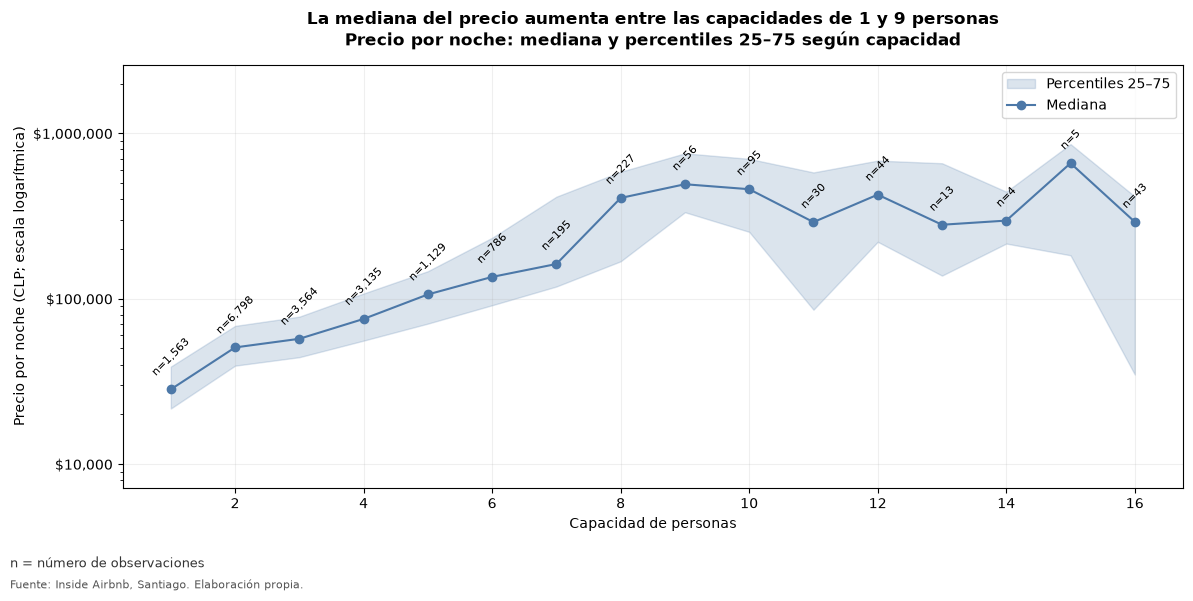

In [27]:
base_capacidad = base_precios.loc[
    np.isfinite(base_precios[col_capacidad_g])
    & (base_precios[col_capacidad_g] > 0)
].copy()

resumen_capacidad = (
    base_capacidad.groupby(col_capacidad_g)[col_precio_g]
    .agg(
        mediana="median",
        q25=lambda serie: serie.quantile(0.25),
        q75=lambda serie: serie.quantile(0.75),
        cantidad="size",
    )
    .sort_index()
)

x = resumen_capacidad.index.to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    x,
    resumen_capacidad["q25"].to_numpy(),
    resumen_capacidad["q75"].to_numpy(),
    color="#4C78A8",
    alpha=0.2,
    label="Percentiles 25–75",
)

ax.plot(
    x,
    resumen_capacidad["mediana"].to_numpy(),
    marker="o",
    color="#4C78A8",
    label="Mediana",
)

for capacidad, fila in resumen_capacidad.iterrows():
    ax.annotate(
        f"n={int(fila['cantidad']):,}",
        xy=(capacidad, fila["mediana"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        rotation=45,
    )

ax.set_yscale("log")
ax.yaxis.set_major_formatter(formato_clp)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Capacidad de personas")
ax.set_ylabel("Precio por noche (CLP; escala logarítmica)")
ax.set_title(
    "La mediana del precio aumenta entre las capacidades de 1 y 9 personas\n"
    "Precio por noche: mediana y percentiles 25–75 según capacidad",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.margins(y=0.3)
ax.legend()
ax.grid(alpha=0.2)

finalizar_figura(fig)

### Interpretación del precio según capacidad de personas

Se observa una tendencia creciente de la mediana del precio entre los alojamientos con capacidad para **una y nueve personas**. Esto sugiere que una mayor capacidad suele asociarse con precios por noche más altos.

A partir de las capacidades mayores, la relación deja de ser uniforme y aparecen aumentos y disminuciones de la mediana. Estas fluctuaciones deben interpretarse considerando la menor cantidad de observaciones: por ejemplo, los grupos de 14 y 15 personas contienen solamente cuatro y cinco alojamientos, respectivamente.

La banda sombreada representa los percentiles 25 y 75 y muestra que, incluso entre alojamientos con igual capacidad, existe variación de precios. Esta dispersión puede relacionarse con diferencias de ubicación, tipo de habitación y otras características. La capacidad corresponde al máximo de personas admitidas, no a huéspedes efectivamente alojados.

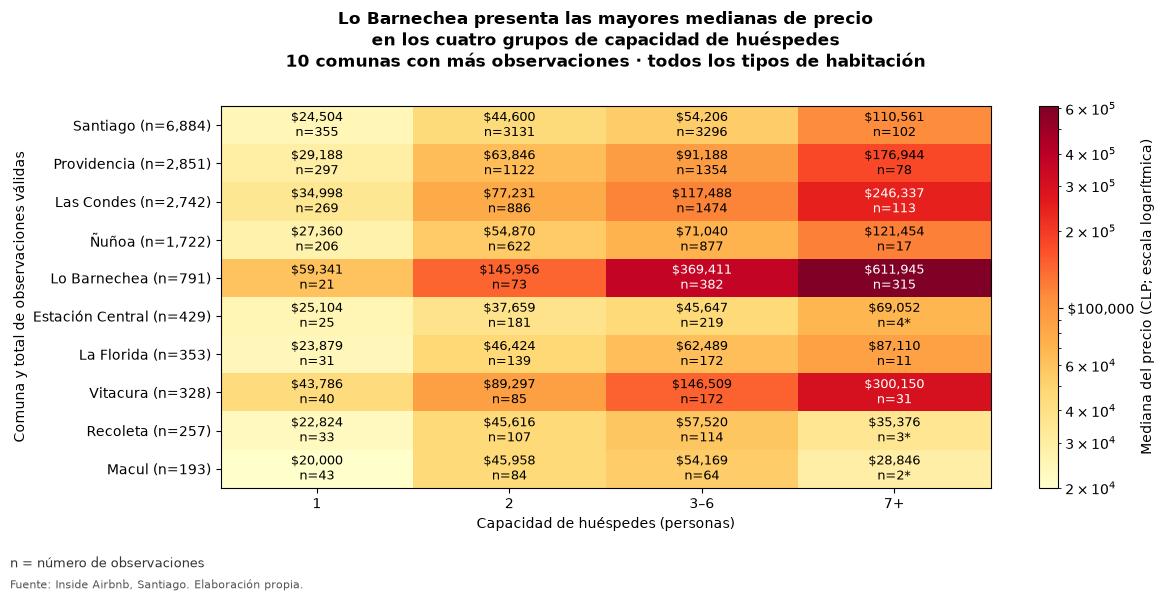

In [28]:
N_COMUNAS = 10
grupos_capacidad = ["1", "2", "3–6", "7+"]

base_mapa_capacidad = base_precios.dropna(
    subset=[col_comuna_g, col_capacidad_g]
).copy()

# La capacidad debe ser positiva, finita y entera.
capacidad = base_mapa_capacidad[col_capacidad_g]

base_mapa_capacidad = base_mapa_capacidad.loc[
    np.isfinite(capacidad)
    & (capacidad >= 1)
    & (capacidad % 1 == 0)
].copy()

base_mapa_capacidad["grupo_huespedes"] = pd.cut(
    base_mapa_capacidad[col_capacidad_g],
    bins=[0, 1, 2, 6, np.inf],
    labels=grupos_capacidad,
    right=True,
)

# Selección según cantidad total de observaciones válidas por comuna.
conteo_capacidad = (
    base_mapa_capacidad.groupby(col_comuna_g)
    .size()
    .sort_values(ascending=False)
)

comunas_capacidad = conteo_capacidad.head(N_COMUNAS).index

base_mapa_capacidad = base_mapa_capacidad.loc[
    base_mapa_capacidad[col_comuna_g].isin(comunas_capacidad)
]

resumen_capacidad_comuna = (
    base_mapa_capacidad
    .groupby(
        [col_comuna_g, "grupo_huespedes"],
        observed=True,
    )[col_precio_g]
    .agg(mediana="median", cantidad="size")
    .reset_index()
)

matriz_mediana = resumen_capacidad_comuna.pivot(
    index=col_comuna_g,
    columns="grupo_huespedes",
    values="mediana",
).reindex(
    index=comunas_capacidad,
    columns=grupos_capacidad,
)

matriz_cantidad = resumen_capacidad_comuna.pivot(
    index=col_comuna_g,
    columns="grupo_huespedes",
    values="cantidad",
).reindex(
    index=comunas_capacidad,
    columns=grupos_capacidad,
)

valores = matriz_mediana.to_numpy(dtype=float)
validos = valores[np.isfinite(valores)]

if validos.size == 0:
    raise ValueError("No hay datos válidos para construir el mapa.")

minimo, maximo = validos.min(), validos.max()
if minimo == maximo:
    minimo, maximo = minimo / 1.1, maximo * 1.1

paleta = plt.get_cmap("YlOrRd").copy()
paleta.set_bad("#E5E5E5")

fig, ax = plt.subplots(
    figsize=(12, max(6, len(comunas_capacidad) * 0.55))
)

imagen = ax.imshow(
    np.ma.masked_invalid(valores),
    cmap=paleta,
    norm=LogNorm(vmin=minimo, vmax=maximo),
    aspect="auto",
)

ax.set_xticks(np.arange(len(grupos_capacidad)))
ax.set_xticklabels(grupos_capacidad)

ax.set_yticks(np.arange(len(comunas_capacidad)))
ax.set_yticklabels([
    f"{comuna} (n={conteo_capacidad.loc[comuna]:,})"
    for comuna in comunas_capacidad
])

for fila in range(valores.shape[0]):
    for columna in range(valores.shape[1]):
        mediana = valores[fila, columna]

        if np.isfinite(mediana):
            cantidad = int(matriz_cantidad.iloc[fila, columna])
            marca = "*" if cantidad < 5 else ""

            ax.text(
                columna,
                fila,
                f"${mediana:,.0f}\nn={cantidad}{marca}",
                ha="center",
                va="center",
                fontsize=9,
                color=(
                    "white" if imagen.norm(mediana) > 0.65
                    else "black"
                ),
            )

barra = fig.colorbar(imagen, ax=ax, format=formato_clp)
barra.set_label("Mediana del precio (CLP; escala logarítmica)")

ax.set_xlabel("Capacidad de huéspedes (personas)")
ax.set_ylabel("Comuna y total de observaciones válidas")
ax.set_title(
    "Lo Barnechea presenta las mayores medianas de precio\n"
    "en los cuatro grupos de capacidad de huéspedes\n"
    f"{len(comunas_capacidad)} comunas con más observaciones · "
    "todos los tipos de habitación\n",
    fontsize=12,
    fontweight="bold",
    pad=14,
)

finalizar_figura(fig)

### Interpretación del precio por comuna y capacidad de huéspedes

En la mayoría de las comunas seleccionadas, la mediana del precio aumenta al pasar de alojamientos para **una persona** a las categorías de **dos, tres a seis y siete o más personas**. La tendencia es visible en **Santiago, Providencia, Las Condes, Ñuñoa, Lo Barnechea y Vitacura**.

También se mantienen diferencias geográficas dentro de cada grupo de capacidad. Por ejemplo, para tres a seis personas, **Lo Barnechea** presenta una mediana de 369.411 CLP, frente a 54.206 CLP en Santiago y 45.647 CLP en **Estación Central**. Esto sugiere que la capacidad y la ubicación aportan conjuntamente a describir las diferencias de precio.

En **Recoleta y Macul**, la mediana disminuye en la categoría de siete o más personas, pero esos grupos contienen solamente tres y dos observaciones, respectivamente. Por ello, esas cifras no constituyen evidencia suficiente de una tendencia general. Además, el gráfico reúne todos los tipos de habitación y la categoría 7+ incluye capacidades distintas, lo que limita la comparación entre alojamientos equivalentes.

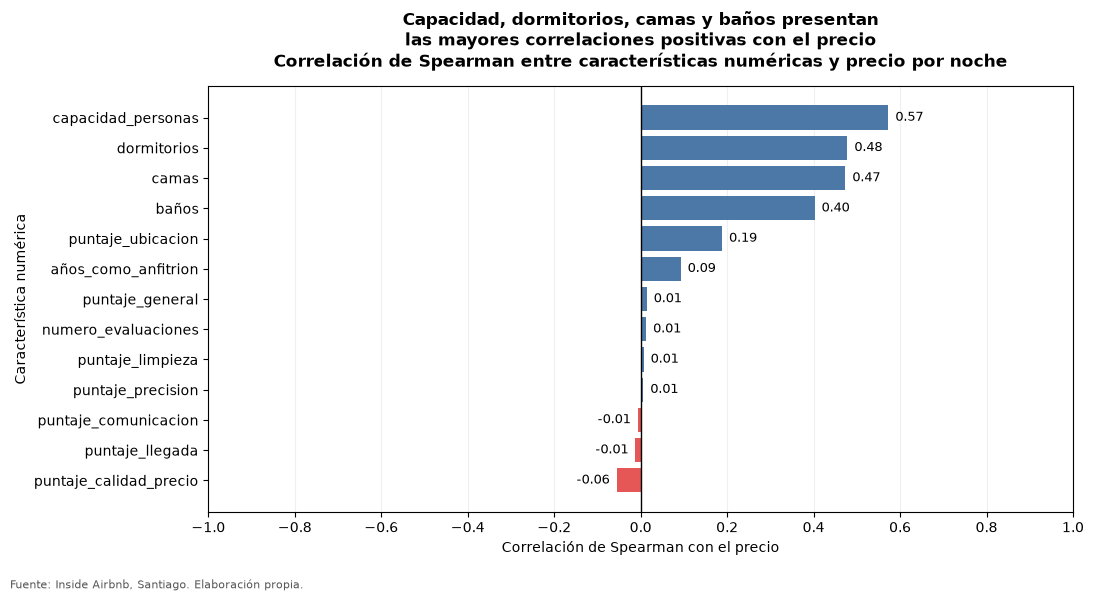

In [29]:
numericas = base_precios.select_dtypes(include="number").copy()
numericas = numericas.replace([np.inf, -np.inf], np.nan)

identificadores = [
    columna for columna in numericas.columns
    if columna.lower() in ("id", "host_id", "scrape_id", "identificador")
    or columna.lower().endswith("_id")
]

numericas = numericas.drop(columns=identificadores)
numericas = numericas.loc[
    :, (numericas.nunique() > 1) & (numericas.count() >= 3)
]

if col_precio_g not in numericas.columns:
    raise ValueError("El precio no tiene suficientes datos o variación.")

correlacion_precio = (
    numericas.corr(method="spearman")[col_precio_g]
    .drop(col_precio_g)
    .dropna()
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(11, max(6, len(correlacion_precio) * 0.45))
)

colores = [
    "#4C78A8" if valor >= 0 else "#E45756"
    for valor in correlacion_precio.values
]

ax.barh(
    correlacion_precio.index,
    correlacion_precio.values,
    color=colores,
)

for posicion, valor in enumerate(correlacion_precio.values):
    ax.annotate(
        f"{valor:.2f}",
        xy=(valor, posicion),
        xytext=(5 if valor >= 0 else -5, 0),
        textcoords="offset points",
        ha="left" if valor >= 0 else "right",
        va="center",
        fontsize=9,
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(-1, 1)
ax.set_xticks(np.arange(-1, 1.01, 0.2))
ax.set_xlabel("Correlación de Spearman con el precio")
ax.set_ylabel("Característica numérica")
ax.set_title(
    "Capacidad, dormitorios, camas y baños presentan\n"
    "las mayores correlaciones positivas con el precio\n"
    "Correlación de Spearman entre características numéricas y precio por noche",
    fontsize=12,
    fontweight="bold",
    pad=14,
)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

finalizar_figura(fig)

### Interpretación de la asociación de variables con el precio

Se observa que **capacidad de personas, dormitorios, camas y baños** presentan las mayores asociaciones positivas con el precio entre las variables analizadas. Esto indica que los alojamientos con mayor capacidad y más espacios o equipamiento suelen ofrecerse a precios más altos.

El **puntaje de ubicación** presenta una asociación positiva con el precio: los alojamientos mejor evaluados en este aspecto tienden a tener precios mayores. Por su parte, la asociación negativa del **puntaje de calidad-precio** sugiere que los alojamientos de menor precio suelen recibir mejores valoraciones en esa dimensión. 

Estas correlaciones describen asociaciones y no demuestran causalidad ni el efecto independiente de cada variable sobre el precio.


## 10 Síntesis de resultados

La distribución territorial de los anuncios es desigual: Santiago concentra la mayor cantidad, seguida de Providencia, Las Condes y Ñuñoa. Esta concentración condiciona la estabilidad de las estadísticas de cada comuna.

El precio varía según tipo de habitación y ubicación. En las comunas seleccionadas, los alojamientos completos presentan medianas superiores a las habitaciones privadas. Lo Barnechea destaca por sus precios centrales altos dentro de los grupos comparados.

La capacidad presenta una relación positiva con el precio, especialmente entre una y nueve personas. Las diferencias dentro de cada capacidad muestran que este atributo no explica por sí solo la variación observada.

Las correlaciones de Spearman sitúan capacidad, dormitorios, camas y baños como las características numéricas de mayor asociación positiva con el precio entre las variables analizadas.

## Discusión y limitaciones

Los hallazgos respaldan una asociación descriptiva del precio con ubicación, tipo de habitación y características físicas. Sin embargo, no permiten identificar el efecto independiente de cada característica: los alojamientos de mayor capacidad también pueden tener más dormitorios, camas y baños.

Las comparaciones por comuna y tipo de habitación reducen parte de la heterogeneidad, pero no controlan simultáneamente capacidad, equipamiento y otras características. Asimismo, algunos grupos tienen muy pocas observaciones y sus medianas deben interpretarse con cautela.

La imputación conserva registros, pero introduce valores repetidos que pueden modificar las distribuciones y correlaciones. El análisis utiliza una captura de anuncios y no incorpora ocupación efectiva, ingresos, estacionalidad ni cambios de precio.

Las conclusiones describen el archivo utilizado. No se extrapolan automáticamente a todo el mercado de alojamiento ni se interpretan como relaciones causales.

## Conclusiones

El proyecto caracteriza las diferencias de precio de los anuncios Airbnb analizados mediante un flujo modular, verificable y documentado. Los resultados indican asociaciones con la ubicación, el tipo de habitación y la capacidad, complementadas por las características físicas del alojamiento.

La copia interpretable permite comunicar los resultados en categorías legibles y CLP, mientras que la matriz transformada conserva una salida numérica para desarrollos posteriores.

## Reflexión técnica y líneas de mejora

La organización en módulos separa responsabilidades y la interfaz común de los transformadores permite coordinar pasos diferentes mediante polimorfismo. Strategy facilita comparar alternativas de escalamiento sin cambiar el orquestador.

La comparación con F2 verifica continuidad del procesamiento. Las pruebas de excepciones y copia defensiva complementan esa comprobación y reducen el riesgo de aceptar resultados incorrectos.

Las mediciones muestran el rendimiento de dos implementaciones de una operación concreta; no demuestran por sí solas la eficiencia del pipeline completo.

Como líneas de mejora se propone:

- Comparar las asociaciones usando valores observados frente a valores imputados.
- Revisar valores extremos en sus unidades originales y con información de la fuente.
- Comparar alojamientos con igual tipo de habitación y capacidad dentro de cada comuna.
- Medir tiempo y memoria del procesamiento completo.
- Incorporar otras fechas para estudiar estabilidad temporal.
- Si se desarrolla un modelo predictivo, separar entrenamiento y prueba antes de ajustar las transformaciones.

## 11. Bibliografía (APA 7)

- Inside Airbnb. (2026). *Santiago, Región Metropolitana de Santiago: Detailed listings data (June 29, 2026)* [Data file].
- Salinas, O. (2026). *Estructura profesional de un proyecto Python* [Apunte]. Universidad Andrés Bello.
- Universidad Andrés Bello. (2026). *Guía de desarrollo — Evaluación Sumativa 1 (Fases 1 y 2)* [Documento de apoyo].
- The pandas development team. (2024). *pandas documentation*.
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.


